In [1]:
import sys
sys.path.insert(0, '../..')  # Adjust this if Omama is elsewhere
import omama as O


In [2]:
omama_loader = O.OmamaLoader()
data = O.Data(data_loader=omama_loader, load_cache=True)


Loading config data from ini file
DataLoader type is:  <class 'omama.loaders.omama_loader.OmamaLoader'>


In [3]:
img1 = O.DataHelper.get(image='DXm.2.25.206167974264275502332635069182559542865')
img2 = O.DataHelper.get(image='DXm.2.25.210978074369984818006108371902713613741')
img3 = O.DataHelper.get(image='DXm.2.25.308565539922728484200493246130055771080')
img4 = O.DataHelper.get(image='DXm.2.25.54209637931810984318090364091556091553')
img5 = O.DataHelper.get(image='DXm.2.25.85504626148083401893700478006196522125')


In [4]:
import json

with open('/raid/mpsych/OMAMA/2025/PLAYGROUND/out3/2.25.6207211135548877635795580802815855053/results_full.json') as f:
    results = json.load(f)



Prediction(s) for 2.25.206167974264275502332635069182559542865:
  ➤ ROI 1: Score = 0.3494
type of data:  <class 'omama.data.Data'>
bb: [222, 1081, 517, 1350]
  ➤ ROI 2: Score = 0.2115
type of data:  <class 'omama.data.Data'>
bb: [29, 592, 356, 860]
  ➤ ROI 3: Score = 0.1810
type of data:  <class 'omama.data.Data'>
bb: [468, 767, 735, 1044]
  ➤ ROI 4: Score = 0.0497
type of data:  <class 'omama.data.Data'>
bb: [424, 608, 585, 714]
  ➤ ROI 5: Score = 0.0360
type of data:  <class 'omama.data.Data'>
bb: [170, 973, 371, 1076]
  ➤ ROI 6: Score = 0.0328
type of data:  <class 'omama.data.Data'>
bb: [157, 1389, 457, 1673]

Prediction(s) for 2.25.210978074369984818006108371902713613741:
  ➤ ROI 1: Score = 0.3013
type of data:  <class 'omama.data.Data'>
bb: [1305, 1029, 1439, 1156]
  ➤ ROI 2: Score = 0.2068
type of data:  <class 'omama.data.Data'>
bb: [1261, 1425, 1537, 1667]
  ➤ ROI 3: Score = 0.1188
type of data:  <class 'omama.data.Data'>
bb: [1438, 761, 1721, 1018]
  ➤ ROI 4: Score = 0.0752


/home/a.kanamarlapudi001/projects/omama-proj/omama/helpers/data_helper.py:543: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(figsize=(10, 10))


bb: [198, 580, 478, 847]
  ➤ ROI 5: Score = 0.0369
type of data:  <class 'omama.data.Data'>
bb: [652, 1200, 815, 1331]
  ➤ ROI 6: Score = 0.0305
type of data:  <class 'omama.data.Data'>
bb: [1, 1323, 174, 1611]


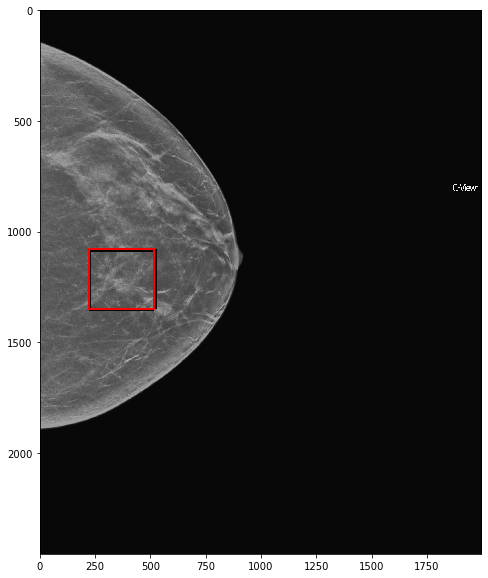

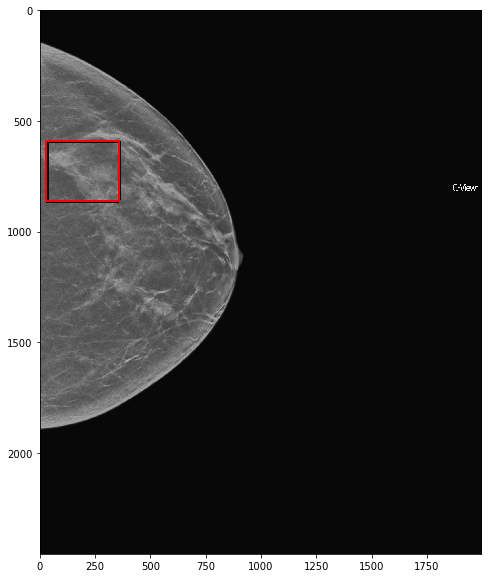

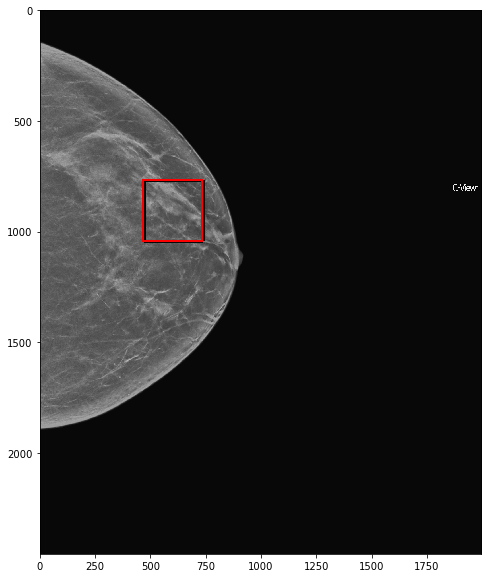

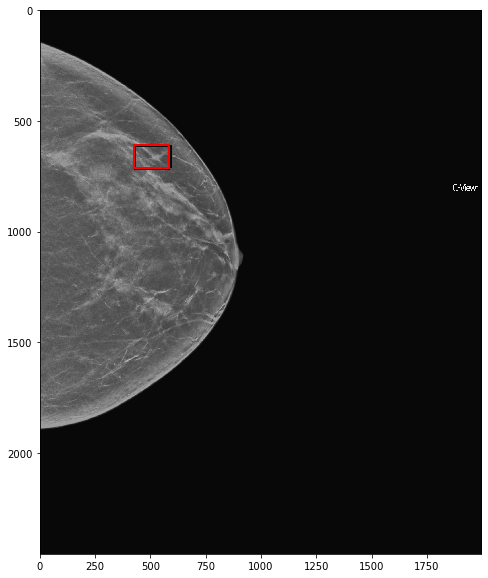

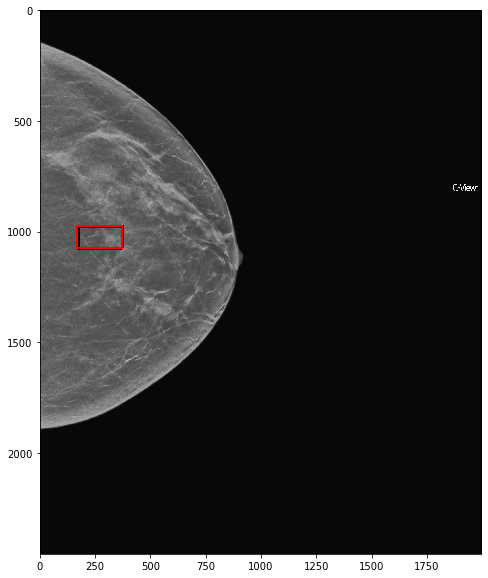

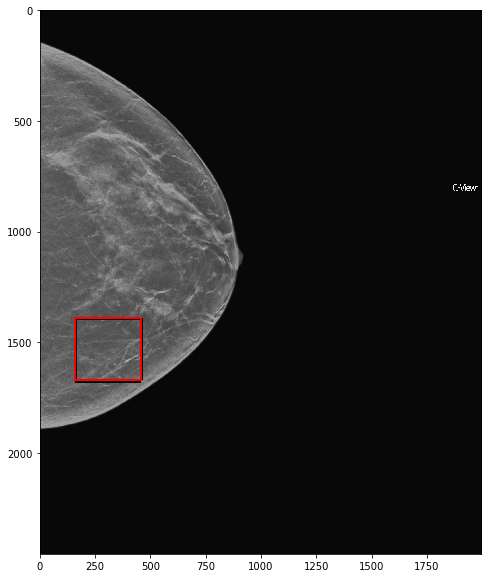

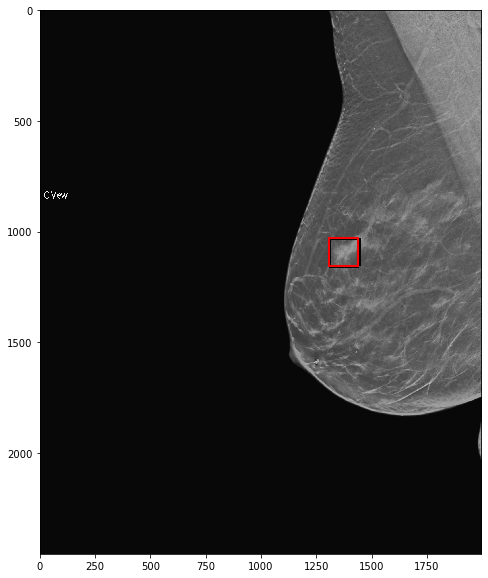

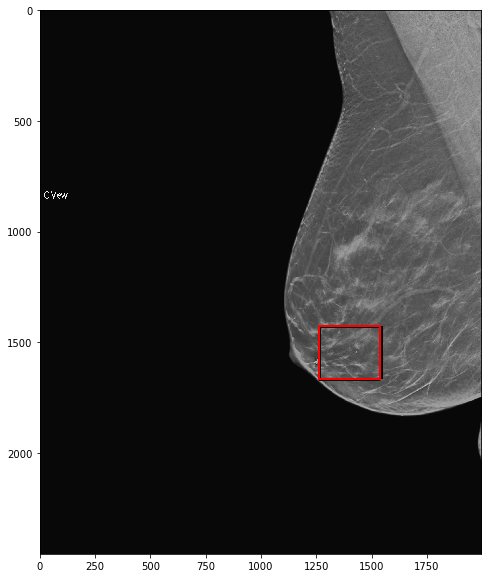

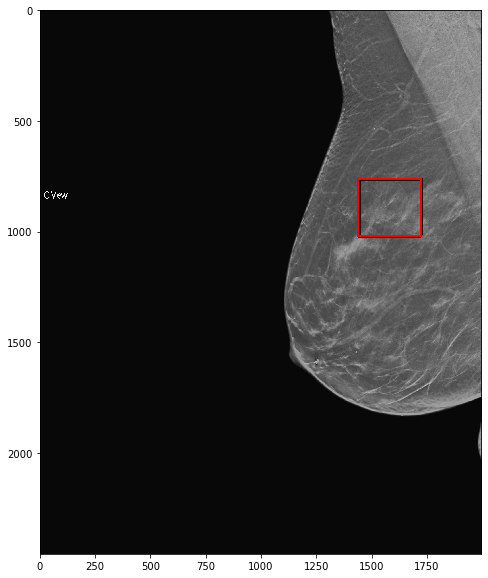

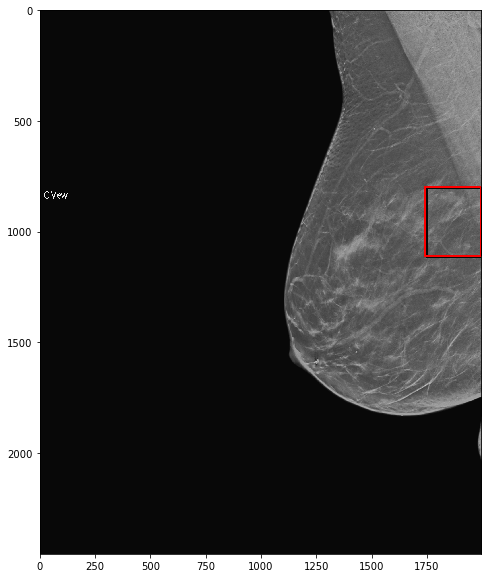

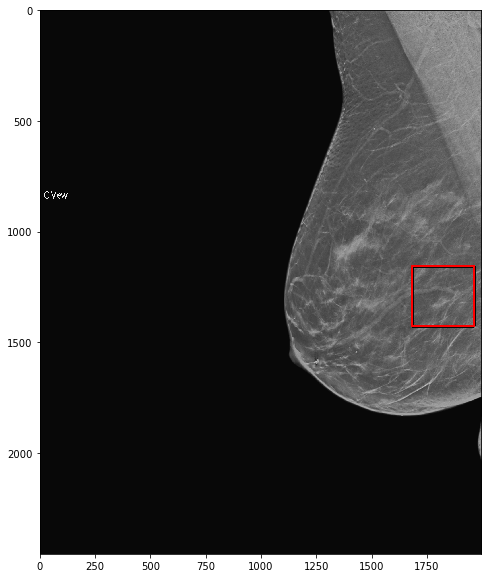

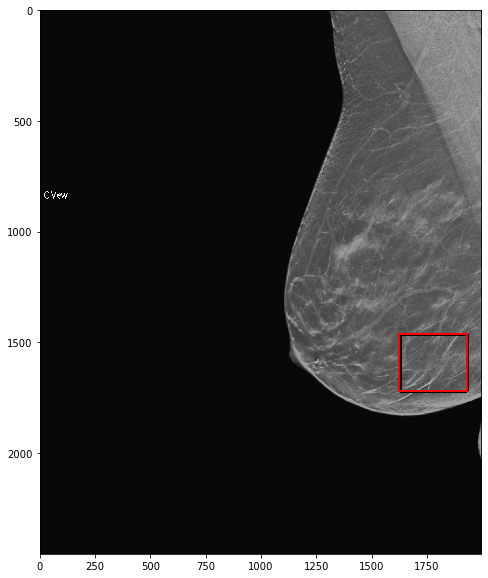

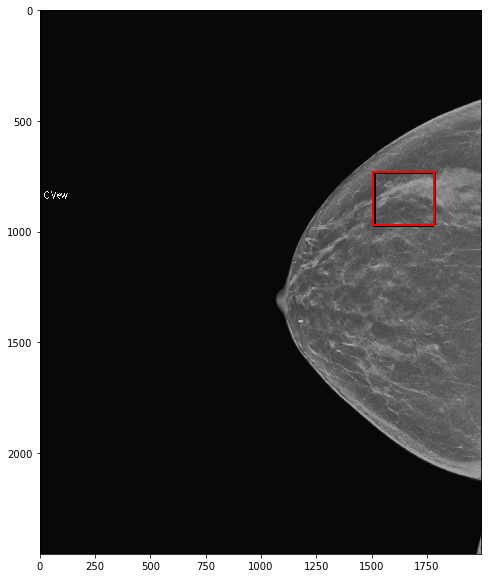

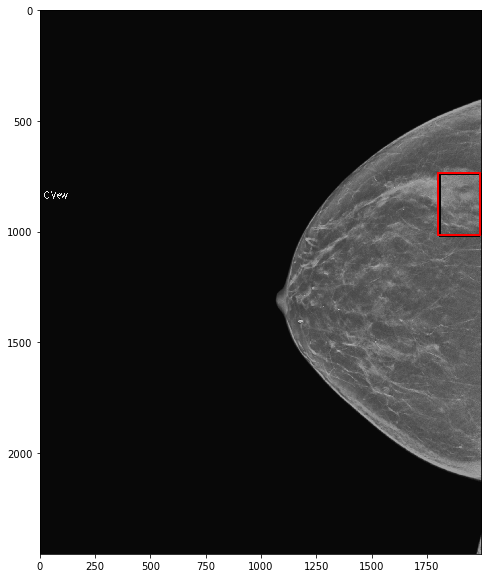

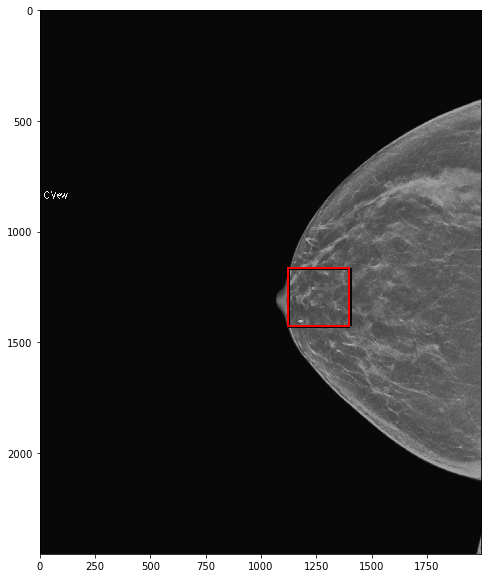

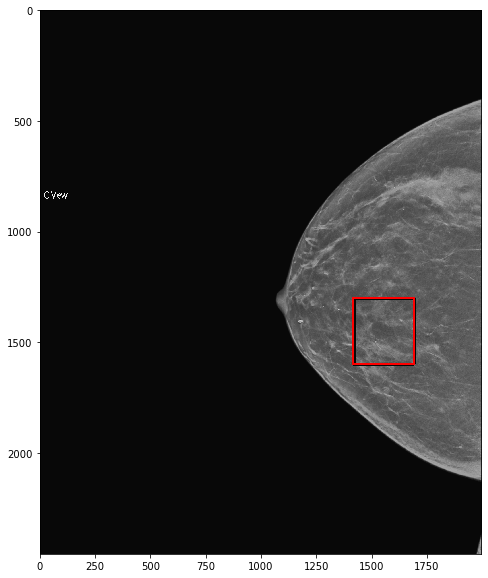

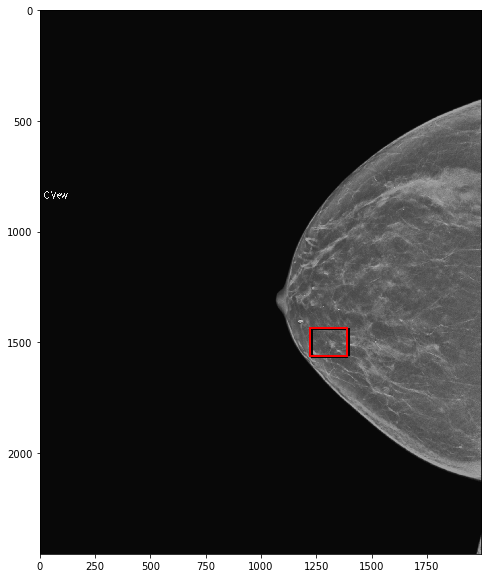

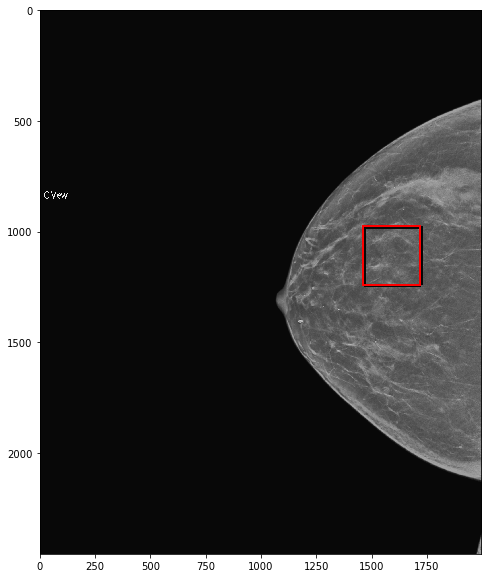

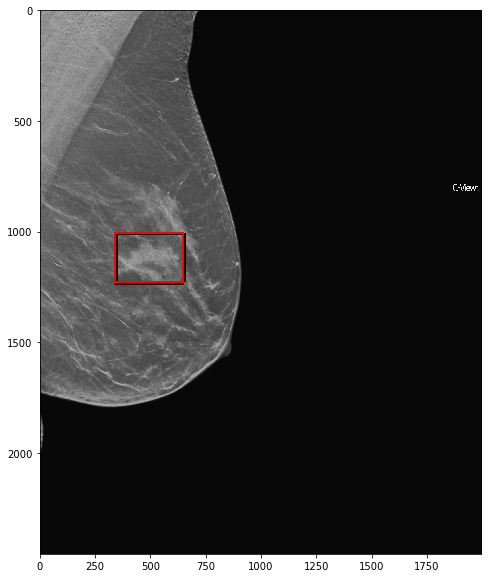

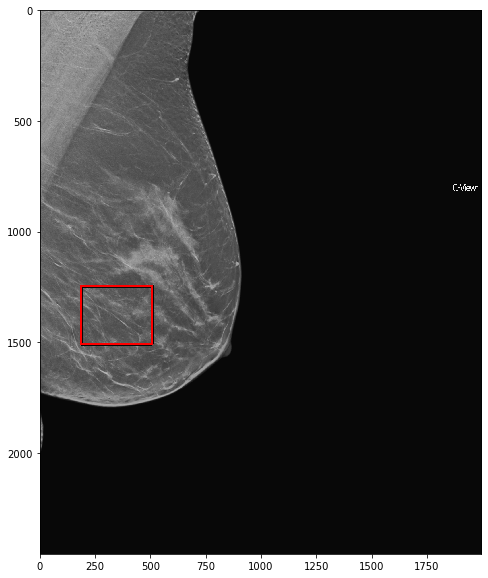

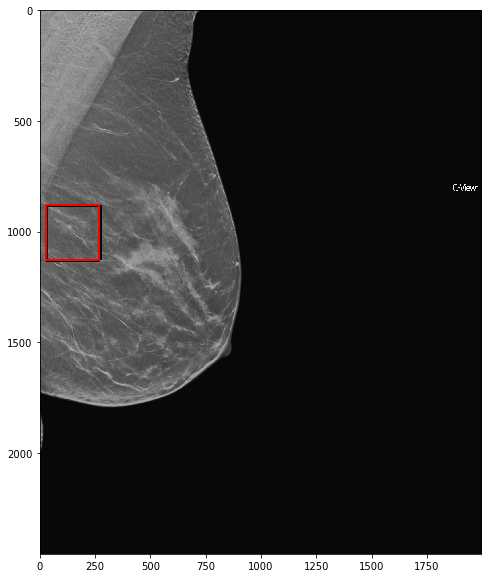

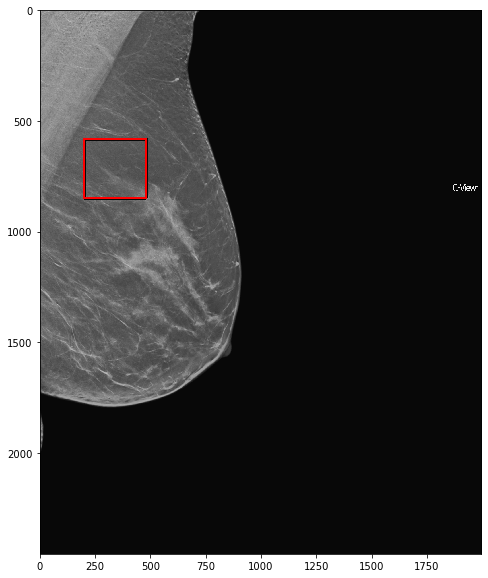

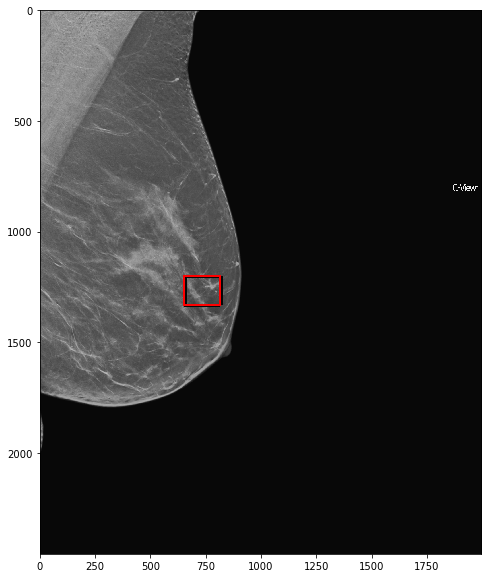

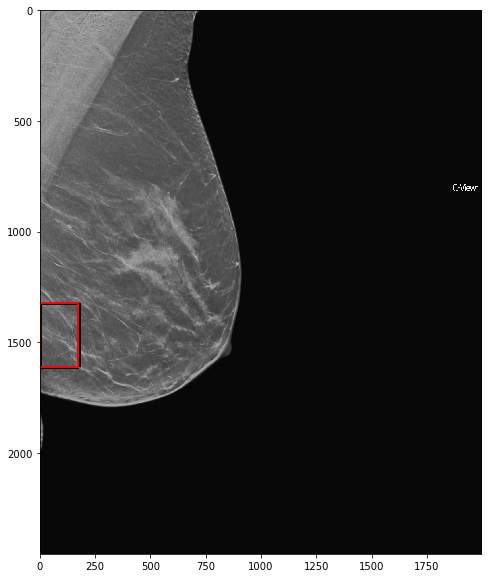

In [5]:
for img in [img1, img2, img3, img4, img5]:
    sop_uid = img.SOPInstanceUID
    if sop_uid in results['results']['dicom_results']:
        predictions = results['results']['dicom_results'][sop_uid]['none']
        print(f"\nPrediction(s) for {sop_uid}:")
        for i, pred in enumerate(predictions):
            coords = pred['coords']
            score = pred['score']
            print(f"  ➤ ROI {i+1}: Score = {score:.4f}")
            O.DataHelper.view(image=img, roi_coords=coords)
    else:
        print(f"\nNo predictions found for image {sop_uid}.")
